In [2]:
%load_ext autoreload
%autoreload 2

import os
os.environ["OPENBLAS_NUM_THREADS"] = "4"  # or a lower number like 2, 4, or 8

import sys, re, torch, time, PINN, palantir
import numpy as np
import pandas as pd
import scanpy as sc
from tqdm.auto import tqdm
# PINN
from PINN import reader, models, pl, tl
# plot
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from matplotlib.backends.backend_pdf import PdfPages

os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [3]:
import decoupler as dc

In [4]:
adata = sc.read_h5ad("data/tom_pos.h5ad")
adata_raw = adata.raw.to_adata()
# gene_trends = palantir.presults.compute_gene_trends(
#     adata_raw,
#     expression_key="MAGIC_imputed_data",
# )

## DoRothEA network
<font size=2.5 color='gray'>
DoRothEA is a comprehensive resource containing a curated collection of TFs and their transcriptional targets. Since these regulons were gathered from different types of evidence, interactions in DoRothEA are classified in different confidence levels, ranging from A (highest confidence) to D (lowest confidence). Moreover, each interaction is weighted by its confidence level and the sign of its mode of regulation (activation or inhibition).

For this example we will use the human version (mouse is also available) and we will use the confidence levels ABC. To access it we can use decoupler.
</font>

In [5]:
net = dc.get_dorothea(organism='mouse', levels=['A','B','C'])
net = net.drop_duplicates(subset=['source', 'target'])
net

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/liana/resource/_orthology.py:199: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.


,source,target,weight,confidence
0,Myc,Tert,1.0,A
1,Zeb1,Ar,-1.0,A
2,Stat1,Igfbp3,1.0,A
3,Ets1,Cd4,1.0,A
4,Foxa1,Rprm,-1.0,A
...,...,...,...,...
30663,Nfe2,Kcnma1,0.333333,C
30664,Irf1,Ube2l6,0.333333,C
30665,Cdx2,Pdlim5,0.333333,C
30666,Cdx2,Mylk,0.333333,C


## Activity inference with Multivariate Linear Model

<font size=2.5>
To infer activities we will run the Multivariate Linear Model method (mlm). It models the observed gene expression by using a regulatory adjacency matrix (target genes x TFs) as covariates of a linear model. The values of this matrix are the associated interaction weights. The obtained t-values of the fitted model are the activity scores.

To run decoupler methods, we need an input matrix (mat), an input prior knowledge network/resource (net), and the name of the columns of net that we want to use.</font>

In [ ]:
dc.run_mlm(mat=adata, net=net, 
           source='source', target='target', 
           weight='weight', verbose=True)

adata.obsm['mlm_estimate']

In [ ]:
adata.obsm['mlm_estimate'].to_csv("data/tompos_decoupleR_TFactivity.csv", index=True)

# Resume

In [7]:
ad_palantir = sc.read_h5ad("data/tom_pos_palantir_Jun4.h5ad")
# ad_palantir.obsm['mlm_estimate'] = adata.obsm['mlm_estimate'].copy()
ad_palantir.obsm['mlm_estimate'] = pd.read_csv("data/tompos_decoupleR_TFactivity.csv", index_col=0)
ad_palantir

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [8]:
# Create a new AnnData object using adata.obsm[mlm_estimate_key] as X,
    # and inherit obs, obsm, obsp from the original AnnData.
acts = dc.get_acts(ad_palantir, obsm_key='mlm_estimate')
acts

AnnData object with n_obs × n_vars = 49390 × 288
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [9]:
mean_acts = dc.summarize_acts(acts, groupby='anno_man', min_std=0.5)
mean_acts

,Atf6,Batf,Cebpe,E2f2,E2f4,Fli1,Foxp1,Gata1,Gfi1b,Hbp1,...,Nr2c2,Rfx1,Runx3,Spi1,Stat1,Tcf4,Tfdp1,Vdr,Zfp143,Zhx1
Bas/MC prog,4.731568,0.079567,0.244913,0.785292,9.576818,-0.297070,1.457285,-0.276980,0.643401,-0.326448,...,5.922189,0.295525,-1.424421,3.702600,0.776013,0.602615,2.799024,3.840769,0.767628,-0.501408
Eos,6.784254,-0.927625,0.857305,2.873004,8.890664,-1.970404,0.930610,0.137179,-0.008640,-1.957682,...,7.024271,1.580478,-1.287126,4.740219,-1.313584,-0.986619,2.244833,4.969694,-0.782991,-2.520568
Ery,2.693029,0.179267,-1.440881,0.738841,9.818343,-0.313505,1.477213,0.316300,1.210321,-0.881158,...,6.558531,-0.041237,-0.954628,1.035634,0.052987,-0.058904,2.812652,3.568650,0.476647,-0.144282
HSC,2.976753,0.396036,-1.152830,0.308427,6.723789,-0.420298,2.251866,-0.070053,1.374802,-0.412907,...,5.216337,0.298678,-0.544348,2.681883,0.716850,0.471973,1.325240,3.264371,0.382619,-0.378445
Int prog,4.133743,0.085818,-0.118030,1.010441,9.201722,-0.661151,1.627571,-0.202699,1.357008,-1.105035,...,6.104336,0.190823,-1.014782,3.551278,0.161471,0.428651,2.727103,3.606849,0.703097,-0.679510
Ly,3.175684,0.516930,-1.110879,0.845625,8.015884,-1.195282,2.063109,-0.503589,2.346517,-1.211578,...,5.657177,0.102570,0.091378,3.373195,0.291466,0.310331,2.523561,3.567602,0.759785,-0.468585
Meg,4.027280,0.472587,-1.138355,1.184388,9.716404,0.339367,1.671741,2.554313,2.536259,-0.902430,...,6.252490,0.084939,-1.605104,1.886287,-0.100711,0.447114,2.936859,3.349327,0.557490,-0.603374
Mono/DC prog,5.163879,-0.179579,0.837079,1.164559,9.939934,-1.234248,1.048035,-0.598123,1.567832,-1.621463,...,6.538977,0.036420,-1.133779,5.056918,0.069546,0.646805,3.215160,3.803941,0.843498,-0.684017
Neu,6.383020,-0.644230,2.173897,0.916533,8.740237,-0.890304,0.743816,-0.737736,0.711734,-1.837165,...,6.612001,-0.022837,-1.249591,5.466204,-0.402417,0.150429,2.744967,3.569799,0.707645,-0.860351


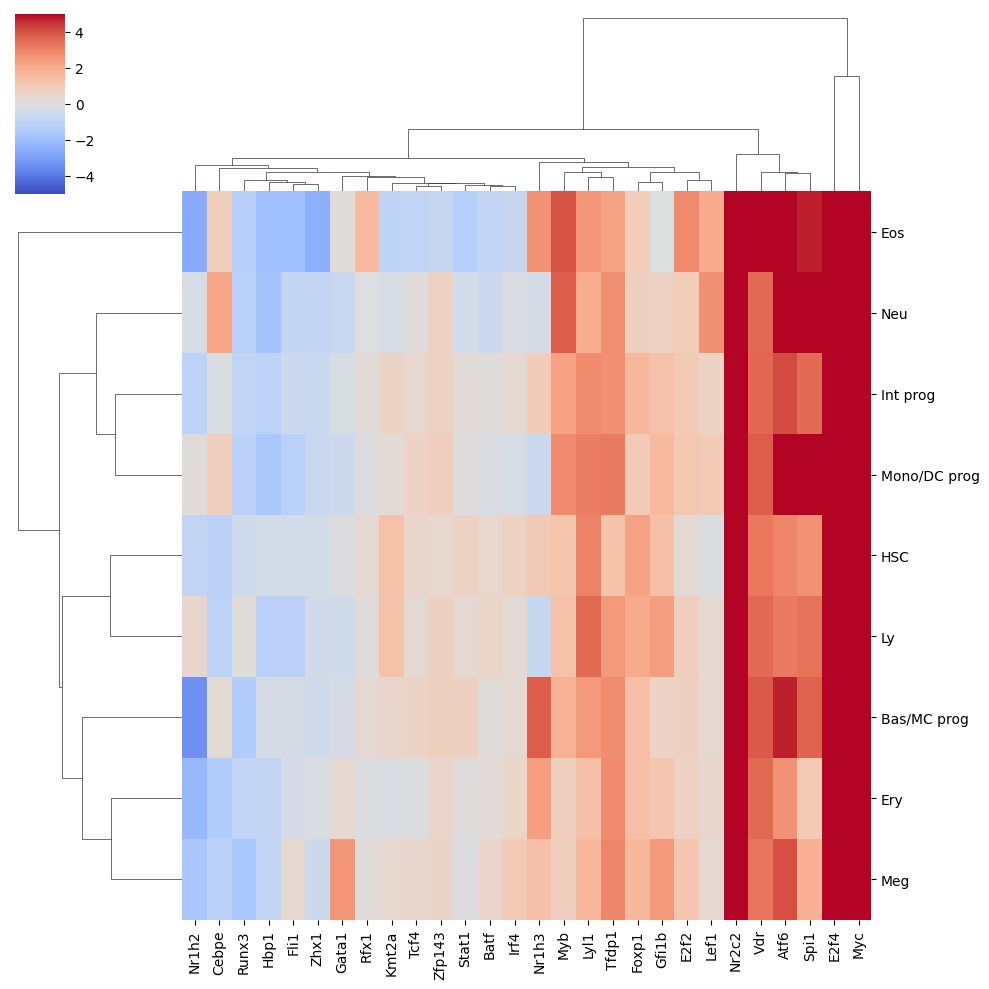

In [10]:
sns.clustermap(mean_acts, xticklabels=mean_acts.columns, vmin=-5, vmax=5, cmap='coolwarm')
plt.show()

In [11]:
#  Compute TF trends along palantir pseudotime
tf_trends = palantir.presults.compute_gene_trends(
    acts,
    expression_key=None,  # Use the layer with TF activity
    pseudo_time_key='palantir_pseudotime',
)

Unable to initialize backend 'cuda': 
Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


Bas/MC prog
[2025-06-06 04:38:27,308] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (10,626) and rank = 1.0.
[2025-06-06 04:38:27,309] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-06 04:38:28,587] [INFO    ] Sigma interpreted as element-wise standard deviation.
Mono/DC prog
[2025-06-06 04:38:29,097] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (14,157) and rank = 1.0.
[2025-06-06 04:38:29,098] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-06 04:38:29,842] [INFO    ] Sigma interpreted as element-wise standard deviation.
Neu
[2025-06-06 04:38:30,243] [INFO    ] Using sparse Gaussian Process since n_landmarks (500) < n_samples (23,442) and rank = 1.0.
[2025-06-06 04:38:30,244] [INFO    ] Using covariance function Matern52(ls=1.0).
[2025-06-06 04:38:31,159] [INFO    ] Sigma interpreted as element-wise standard deviation.
Ly
[2025-06-06 04:38:31,619] [INFO    ] Using sparse Gaussian Process s

# compare with inferred parameters

In [12]:
acts

AnnData object with n_obs × n_vars = 49390 × 288
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'lo

In [13]:
adata_lin = {}
v_project = {}
g_project = {}

for lineage in ['Neu', 'Meg', 'Ery']:
    adata_lin[lineage] = acts[acts.obsm['branch_masks'][lineage]].copy()

    v_project[lineage] = tl.aggregate_params_by_pseudotime(adata_lin[lineage], adata_lin[lineage].obsm['v_norm'].T, 
                                            param_names='v', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

    g_project[lineage] = tl.aggregate_params_by_pseudotime(adata_lin[lineage], adata_lin[lineage].obsm['g'].T, 
                                            param_names='g', timepoints=None, 
                                            pseudotime_key='palantir_pseudotime',
                                            nbins=100, return_y=True)

In [14]:
# prior knowledge of TFs involved in hematopoiesis
blood_lineage_tfs = {
    "HSC": ["Gata2", "Runx1", "Tal1", "Lmo2", "Meis1", "Hhex", "Erg"],
    "Erythroid": ["Gata1", "Klf1", "Tal1", "Ldb1", "Hba-a1", "Hba-x", "Bpgm", "Gypa"],
    "Megakaryocyte": ["Gata1", "Gfi1b", "Fli1", "Runx1"],
    "Myeloid_Granulocyte": ["Cebpa", "Spi1", "Gfi1", "Cebpe"],
    "Myeloid_Monocyte": ["Spi1", "Irf8", "Cebpb", "Cd68"],
    "Lymphoid_T": ["Bcl11b", "Gata3", "Tcf7", "Notch1"],
    "Lymphoid_B": ["Ebf1", "Pax5", "Foxo1"],
    "Lymphoid_NK": ["Nfil3", "Eomes", "Id2"],
    "Dendritic_Cell": ["Irf8", "Zbtb46", "Batf3"],
    "Macrophage": ["Spi1", "Irf5", "Mafb"]
}

In [15]:
from importlib import reload
reload(pl)

<module 'PINN.plotting_fns' from '/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/__init__.py'>

### Neu lineage

gene not found : set()
gene not found : set()


Text(0.5, 1.0, 'Neu lineage Day7 growth rate along Myeloid_Granulocyte Markers')

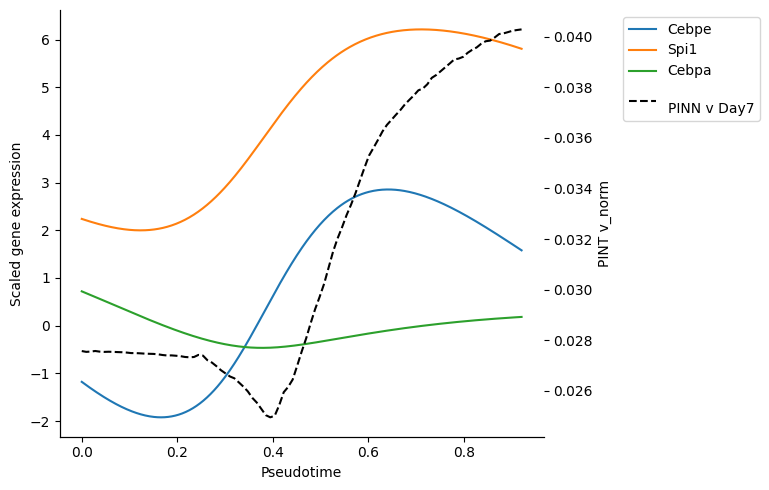

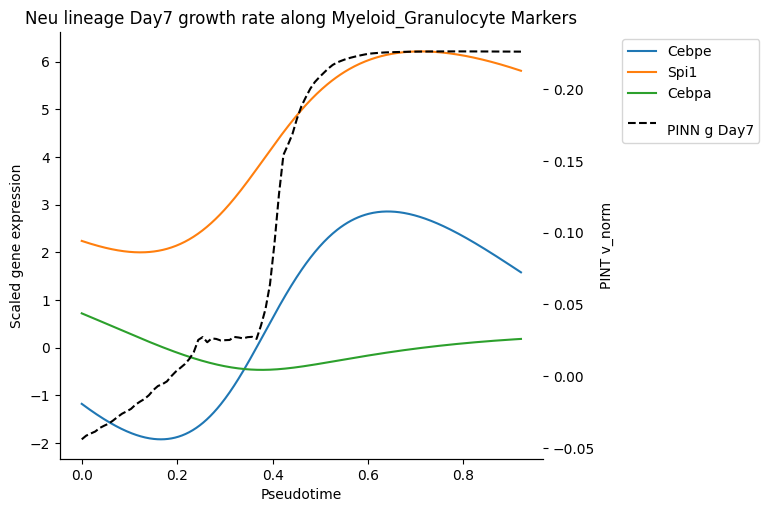

In [59]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Myeloid_Granulocyte'], acts.var_names)

pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Neu'][0],
                    para_name = "\nPINN v Day7")

ax.set_title("Neu lineage Day7 diff rate along Myeloid_Granulocyte Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Neu'],
                    gene_trend_key = 'gene_trends_Neu', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Neu'][0],
                    para_name = "\nPINN g Day7")

ax.set_title("Neu lineage Day7 growth rate along Myeloid_Granulocyte Markers")

gene not found : set()
gene not found : set()


Text(0.5, 1.0, 'Meg lineage Day7 growth rate along HSC Markers')

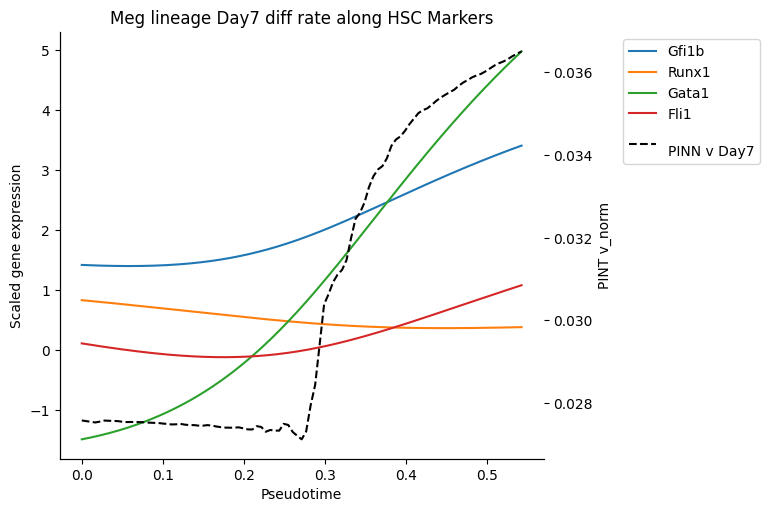

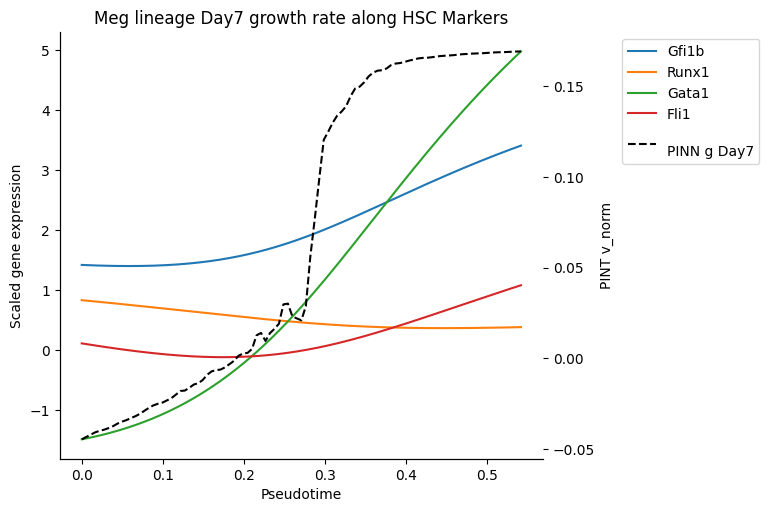

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Megakaryocyte'], acts.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][0],
                    para_name = "\nPINN v Day7")
ax.set_title("Meg lineage Day7 diff rate along Meg Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][0],
                    para_name = "\nPINN g Day7")

ax.set_title("Meg lineage Day7 growth rate along Meg Markers")

### Meg lineage

gene not found : set()
gene not found : set()


Text(0.5, 1.0, 'Ery lineage Day161 growth rate along Erythroid Markers')

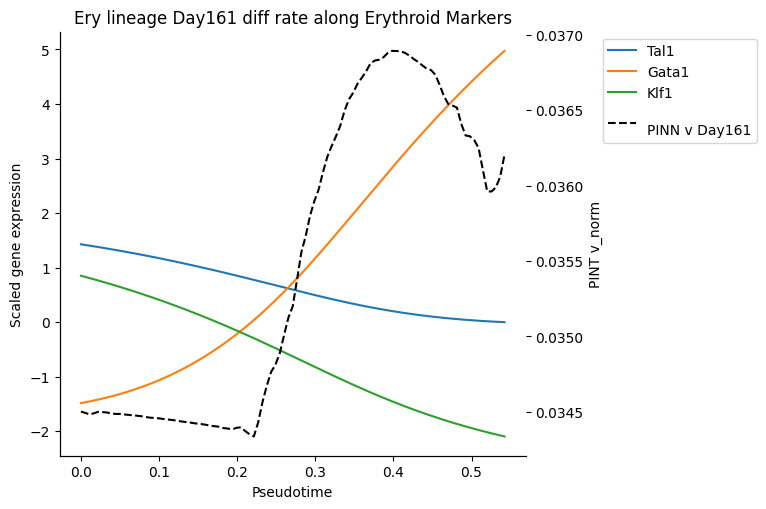

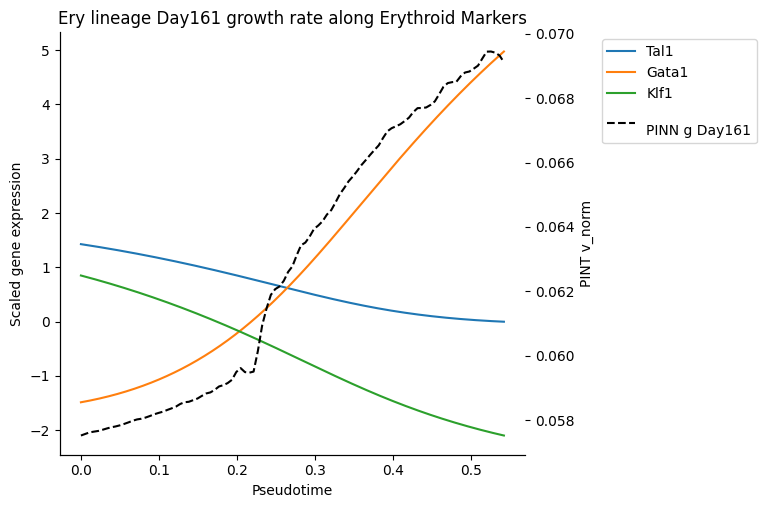

In [62]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Erythroid'], acts.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Ery'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Ery'][-2],
                    para_name = "\nPINN v Day161")
ax.set_title("Ery lineage Day161 diff rate along Erythroid Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Ery'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Ery'][-2],
                    para_name = "\nPINN g Day161")

ax.set_title("Ery lineage Day161 growth rate along Erythroid Markers")

### Ery lineage

gene not found : set()
gene not found : set()


Text(0.5, 1.0, 'Meg lineage Day7 growth rate along HSC Markers')

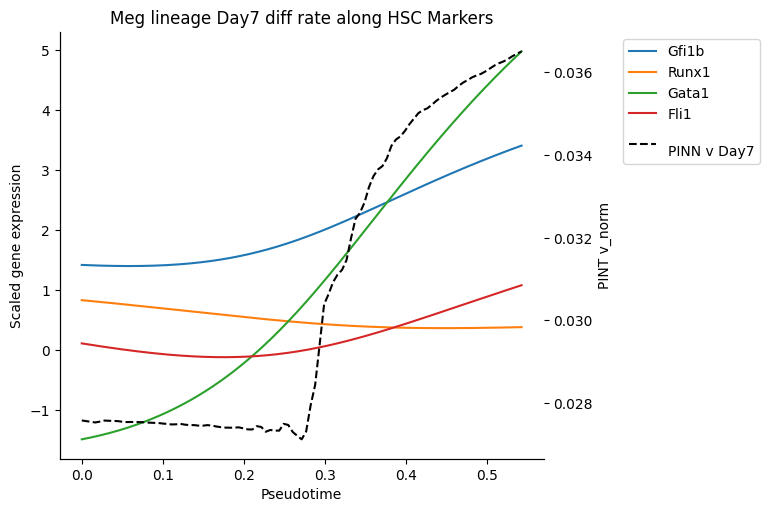

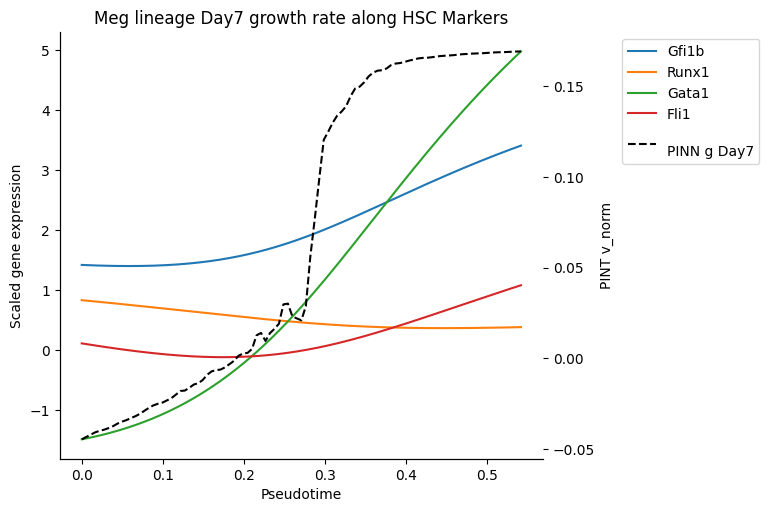

In [ ]:
overlap_genes = np.intersect1d(blood_lineage_tfs['Megakaryocyte'], acts.var_names)

fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = v_project['Meg'][0],
                    para_name = "\nPINN v Day7")
ax.set_title("Meg lineage Day7 diff rate along HSC Markers")


fig, ax, ax2 = pl.plot_gene_trends(adata_lin['Meg'],
                    gene_trend_key = 'gene_trends_Meg', 
                    gene_list= overlap_genes,
                    PINN_params = g_project['Meg'][0],
                    para_name = "\nPINN g Day7")

ax.set_title("Meg lineage Day7 growth rate along HSC Markers")

# Search for correlate genes

In [105]:
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.interpolate import interp1d

def subsample_gene_trends(gene_trends, gt_x, target_x):
    """
    Interpolates gene trends to match the target pseudotime bins.
    gene_trends: DataFrame (genes x pseudotime bins)
    gt_x: array-like, original pseudotime positions of gene trends
    target_x: array-like, target pseudotime positions (e.g., param_curve bins)
    Returns: DataFrame (genes x target pseudotime bins)
    """
    interpolated = []
    TF_index = []
    for gene in gene_trends.index:
        # # skip genes not in the mouse TF list
        # if gene not in mm_tf_found:
        #     continue
        # Interpolate the gene trend to the target pseudotime bins
        f = interp1d(gt_x, gene_trends.loc[gene], kind='linear', fill_value='extrapolate')
        interpolated.append(f(target_x))
        TF_index.append(gene)
    return pd.DataFrame(interpolated, index=TF_index, columns=target_x)


def correlate_gene_trends(gene_trends, param_curve):
    """
    gene_trends: DataFrame (genes x pseudotime bins)
    param_curve: 1D array (same length as pseudotime bins)
    Returns: DataFrame with correlation and p-value for each gene
    """
    results = []
    for gene in gene_trends.index:
        y = gene_trends.loc[gene].values
        corr, pval = stats.pearsonr(y, param_curve)
        results.append({'gene': gene, 'corr': corr, 'pval': pval})
    return pd.DataFrame(results).set_index('gene')


def significant_genes(corr_df, alpha=0.05):
    """
    Apply FDR correction to p-values to identify significantly correlated genes.
    """
    corr_df['fdr'] = multipletests(corr_df['pval'], method='fdr_bh')[1]
    return corr_df[corr_df['fdr'] < alpha].sort_values('corr', ascending=False)


def cluster_gene_trends(gene_trends, n_clusters=3):
    """
    Cluster the significantly correlated genes by their trend curves (e.g., using hierarchical clustering or k-means).
    """
    scaler = StandardScaler()
    X = scaler.fit_transform(gene_trends)
    clustering = AgglomerativeClustering(n_clusters=n_clusters)
    labels = clustering.fit_predict(X)
    return labels

def plot_param_and_clusters(gene_trends, param_curve, cluster_labels, pseudotime_bins):
    
    clusters = np.unique(cluster_labels)
    fig=plt.figure(figsize=(10,4))
    ax1 = fig.gca()
    # Plot parameter curve
    
    # Plot mean ± std for each cluster
    for c in clusters:
        idx = cluster_labels == c
        mean_trend = gene_trends[idx].mean(axis=0)
        std_trend = gene_trends[idx].std(axis=0)
        ax1.plot(pseudotime_bins, mean_trend, label=f'Cluster {c+1}')
        plt.fill_between(pseudotime_bins, mean_trend-std_trend, mean_trend+std_trend, alpha=0.2)

    ax2 = ax1.twinx()
    ax2.plot(pseudotime_bins, param_curve, color='black',linestyle='--',  lw=2, label='Parameter')


    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, bbox_to_anchor=(1.15, 1), loc='upper left')


    plt.xlabel('Scaled Pseudotime')
    ax1.set_ylabel('Expression ')
    # ax2.set_ylabel('\nParameter Value')
    plt.tight_layout()
    plt.show()


In [ ]:
gene_trends_neu = adata_lin['Neu'].varm['gene_trends_Neu']
gt_x = gene_trends_neu.columns.astype(float)  # Convert column names to float for plotting

target_x = np.linspace(0, gt_x.max(), 99)  # Assuming this is the target pseudotime bins
# print(target_x)

[0.         0.00939392 0.01878785 0.02818177 0.03757569 0.04696962
 0.05636354 0.06575746 0.07515139 0.08454531 0.09393923 0.10333316
 0.11272708 0.122121   0.13151492 0.14090885 0.15030277 0.15969669
 0.16909062 0.17848454 0.18787846 0.19727239 0.20666631 0.21606023
 0.22545416 0.23484808 0.244242   0.25363593 0.26302985 0.27242377
 0.2818177  0.29121162 0.30060554 0.30999947 0.31939339 0.32878731
 0.33818124 0.34757516 0.35696908 0.366363   0.37575693 0.38515085
 0.39454477 0.4039387  0.41333262 0.42272654 0.43212047 0.44151439
 0.45090831 0.46030224 0.46969616 0.47909008 0.48848401 0.49787793
 0.50727185 0.51666578 0.5260597  0.53545362 0.54484755 0.55424147
 0.56363539 0.57302931 0.58242324 0.59181716 0.60121108 0.61060501
 0.61999893 0.62939285 0.63878678 0.6481807  0.65757462 0.66696855
 0.67636247 0.68575639 0.69515032 0.70454424 0.71393816 0.72333209
 0.73272601 0.74211993 0.75151386 0.76090778 0.7703017  0.77969563
 0.78908955 0.79848347 0.80787739 0.81727132 0.82666524 0.8360

In [116]:
def pick_gt_and_corr_analysis(lineage, param_curve, n_clusters=4,corr_thres=0.9):
    """
    Perform subsampling, correlation, and clustering for a given lineage.
    lineage: str, e.g., 'Neu', 'Meg', 'Ery'
    param_curve: 1D array of parameter values (e.g., v or g)
    n_clusters: int, number of clusters for hierarchical clustering
    """
   
    gene_trends_neu = adata_lin[lineage].varm[f'gene_trends_{lineage}']
    sub_gene_trend_TFs = subsample_gene_trends(gene_trends_neu, gt_x, target_x)

    # correlate gene trends with the parameter curve
    corr_df = correlate_gene_trends(sub_gene_trend_TFs, param_curve)
    sig_genes = significant_genes(corr_df, alpha=1e-30)
    sig_genes = sig_genes[sig_genes['corr'] > corr_thres]  # Filter for strong correlations
    sig_trends = sub_gene_trend_TFs.loc[sig_genes.index]

    # cluster
    labels = cluster_gene_trends(sig_trends.values, n_clusters=n_clusters)
    sig_genes['cluster'] = labels
    print(f"Number of significant genes: {len(sig_genes)}")
    sig_genes.head()

    # plot
    sig_genes.plot(kind='hist', y='corr', figsize=(10, 4), bins=40, title='Significant Genes Correlation with Growth Rate')
    plot_param_and_clusters(sig_trends.values, param_curve, labels, target_x)
    return sig_genes

In [ ]:
def corr_test_and_plot_clusters(lineage, param_curve, param_name, n_clusters=4, corr_thres=0.9):
    """
    Perform correlation test and plot clusters for a given lineage.
    lineage: str, e.g., 'Neu', 'Meg', 'Ery'
    param_curve: 1D array of parameter values (e.g., v or g)
    param_name: str, name of the parameter and Day (e.g., 'v', 'g')
    n_clusters: int, number of clusters for hierarchical clustering
    """
    
    sig_genes = pick_gt_and_corr_analysis(lineage, param_curve, n_clusters=4, corr_thres=corr_thres)

    figall, axs = plt.subplots(n_clusters, 1, figsize=(6, 3*n_clusters), 
                                sharex=True, gridspec_kw={'hspace': 0.35})
    axs = axs.flatten()

    for group in range(n_clusters):
        genes = sig_genes[sig_genes['cluster'] == group].index
        fig, ax, ax2 = pl.plot_gene_trends(adata_lin[lineage],
                        gene_trend_key = f'gene_trends_{lineage}', 
                        gene_list= genes,
                        PINN_params = param_curve,
                        para_name = param_name,
                        ax = axs[group]
                        )
        ax2.set_yticks([])
        axs[group].set_title(f"TF cluster {group}")

    figall.suptitle(f"{lineage} lineage {param_name} rate along TF clusters")

Number of significant genes: 31


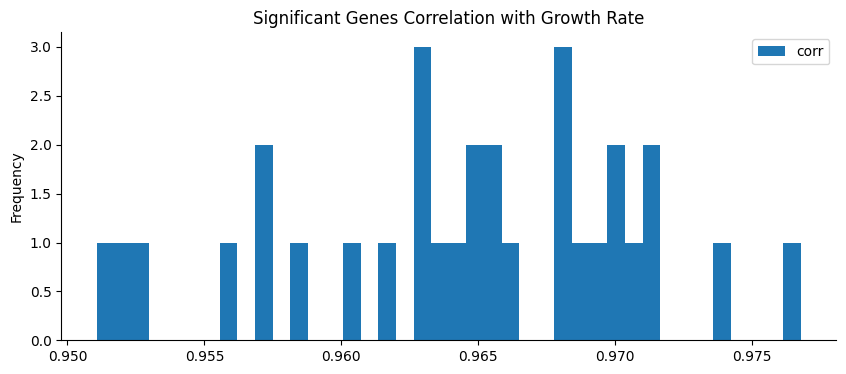

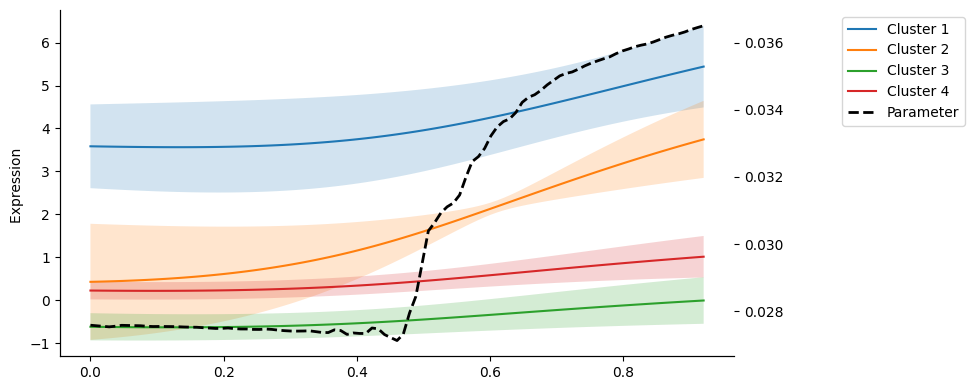

gene not found : set()
gene not found : set()
gene not found : set()
gene not found : set()


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


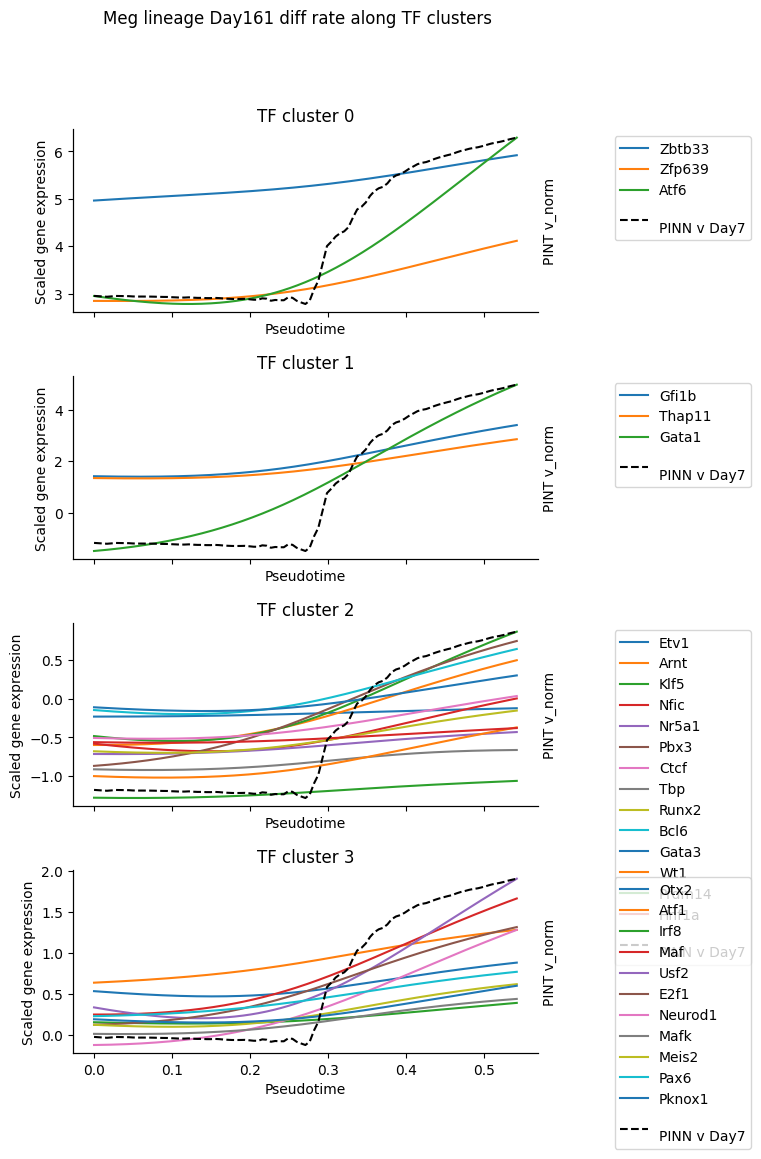

In [118]:
corr_test_and_plot_clusters("Meg", v_project['Meg'][0], "\nPINN v Day7", n_clusters=4, corr_thres=0.95)

Number of significant genes: 37


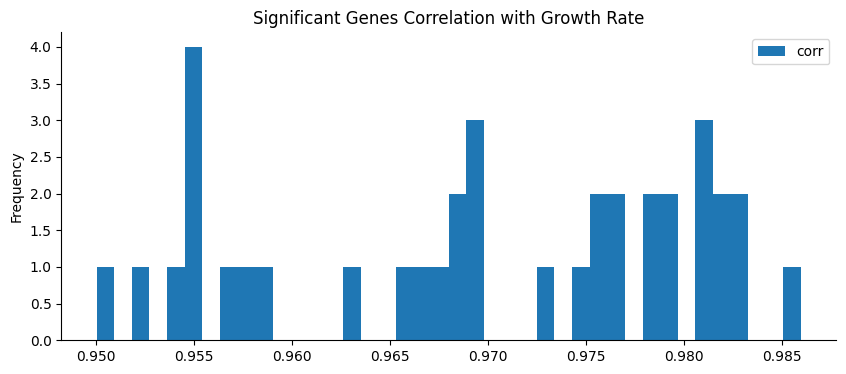

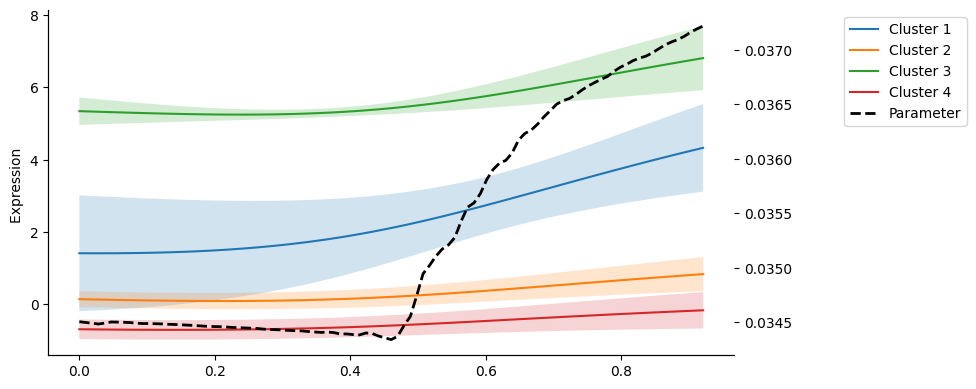

gene not found : set()
gene not found : set()
gene not found : set()
gene not found : set()


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


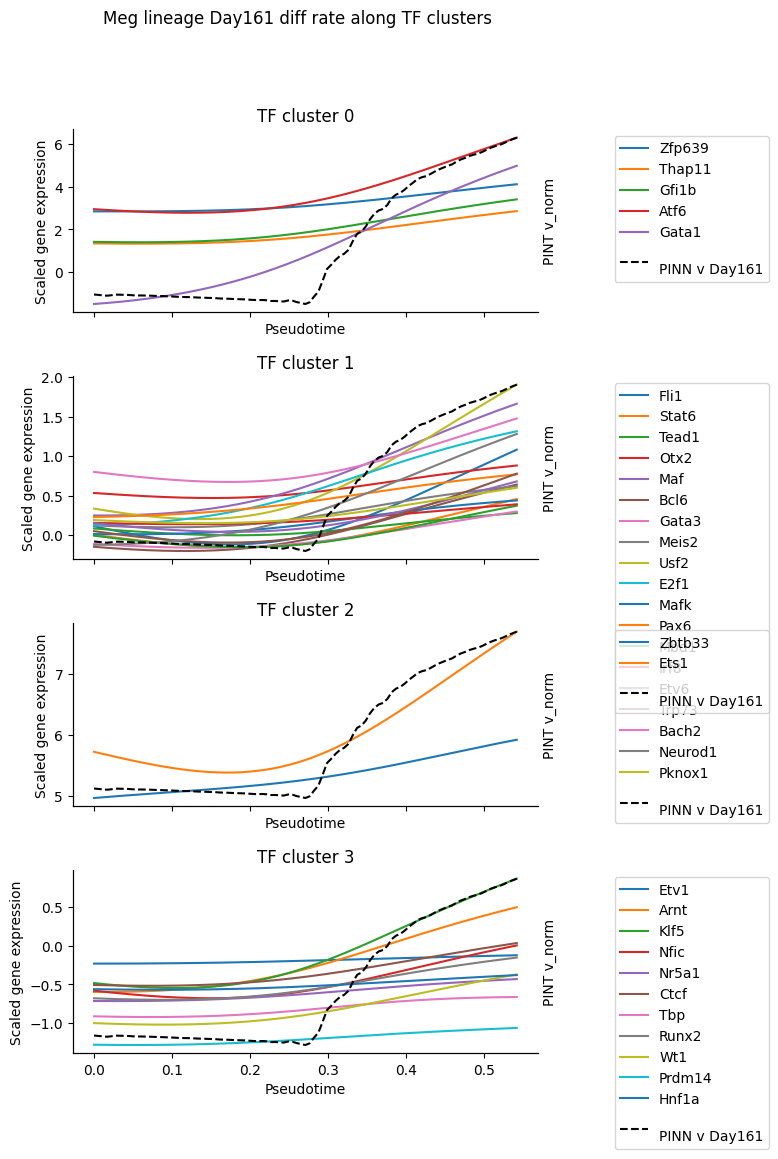

In [119]:
corr_test_and_plot_clusters("Meg", v_project['Meg'][-2], "\nPINN v Day161", n_clusters=4, corr_thres=0.95)

Number of significant genes: 61


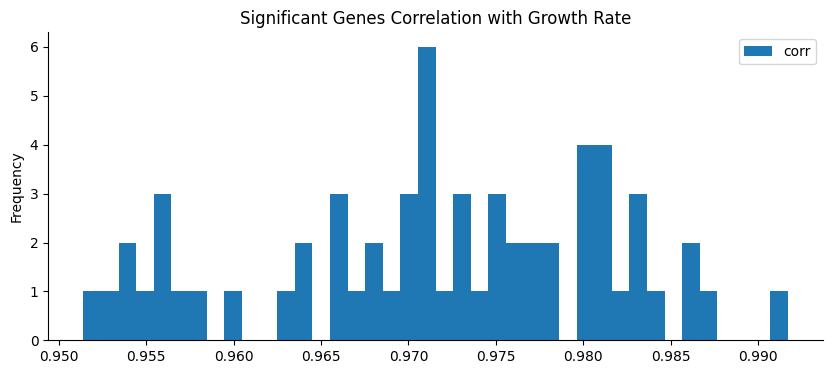

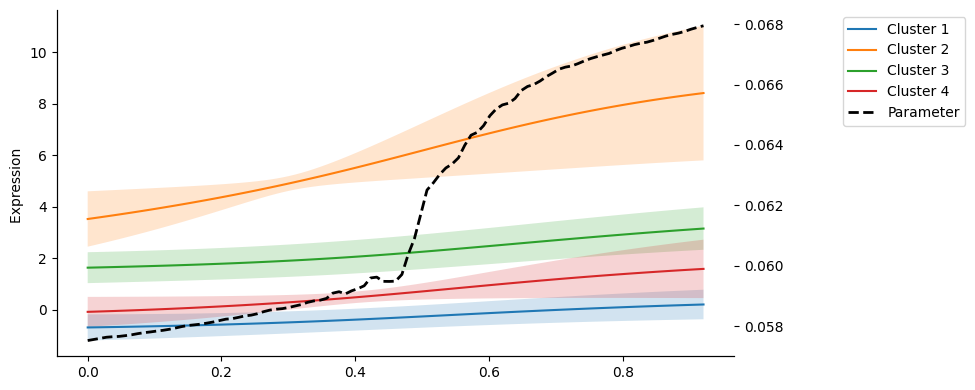

gene not found : set()
gene not found : set()
gene not found : set()
gene not found : set()


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


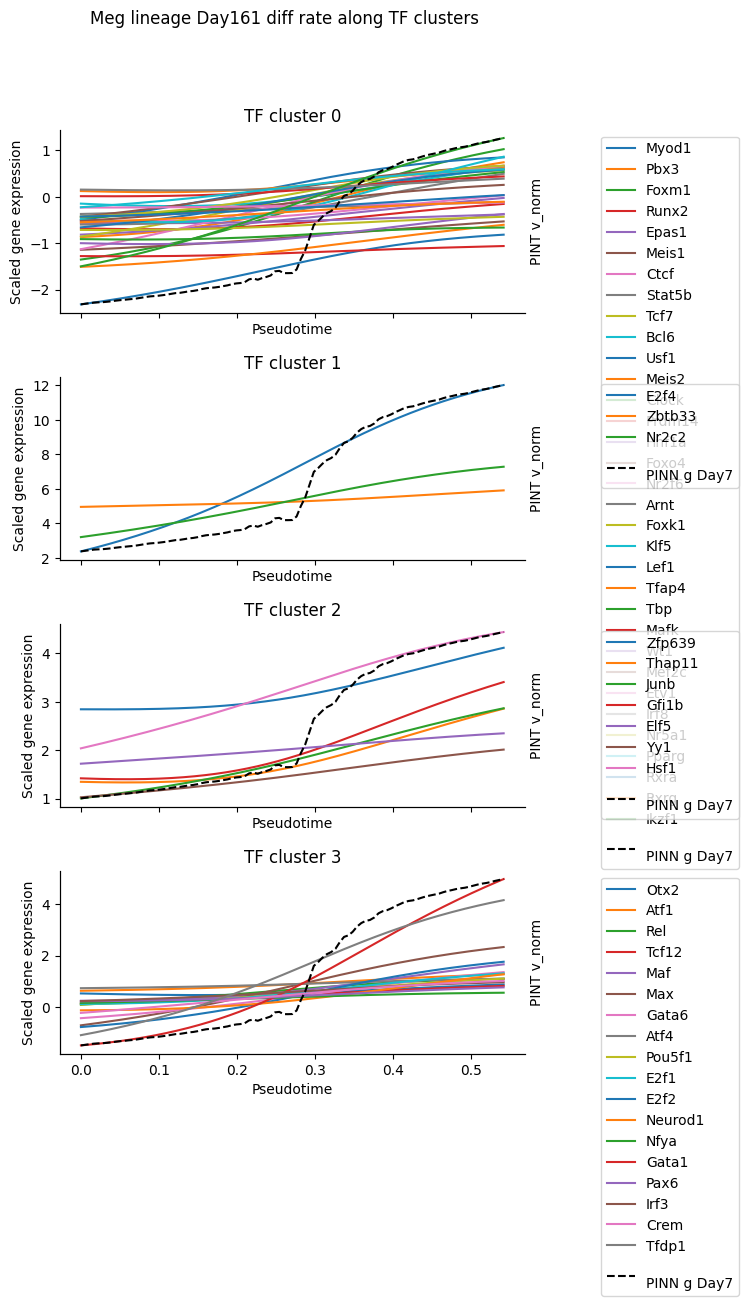

In [120]:
corr_test_and_plot_clusters("Meg", g_project['Meg'][-2], "\nPINN g Day7", n_clusters=4, corr_thres=0.95)

Number of significant genes: 61


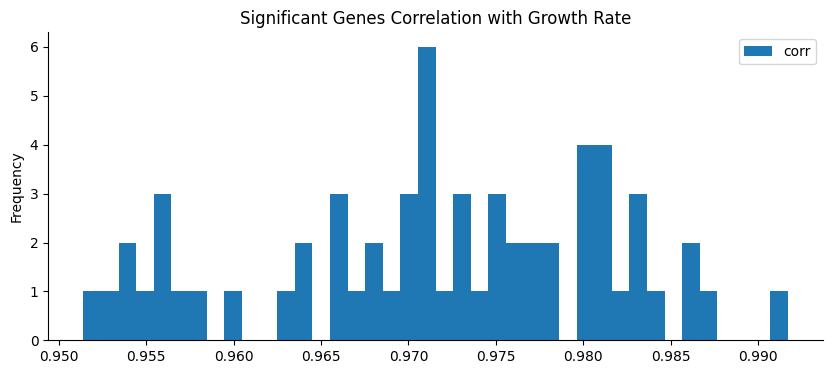

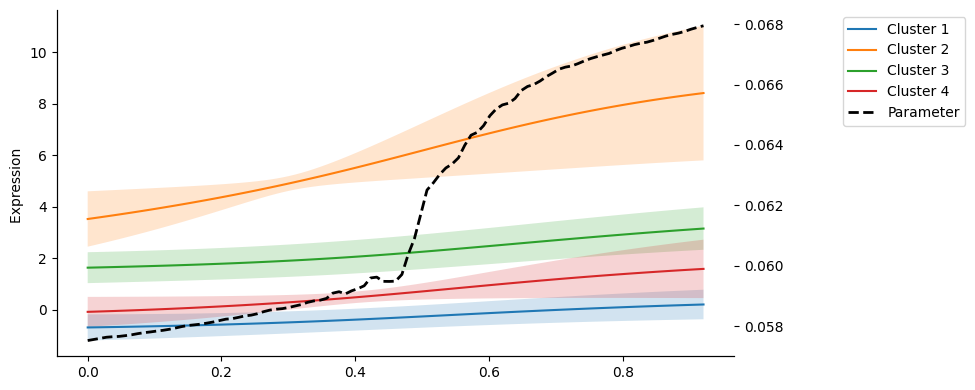

gene not found : set()
gene not found : set()
gene not found : set()
gene not found : set()


/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
/ssd/users/Wergillius/Project/PINN_dynamics/PINN/plotting_fns/param_plot.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


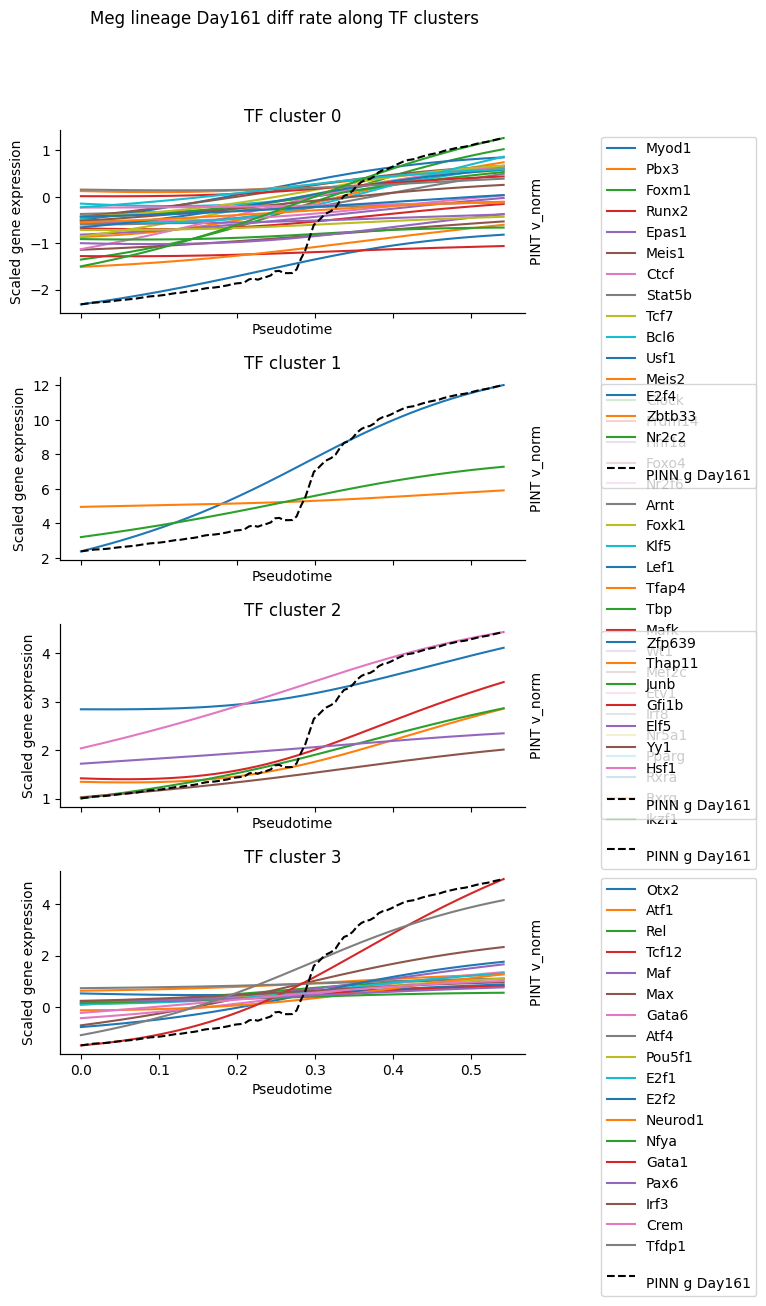

In [121]:
corr_test_and_plot_clusters("Meg", g_project['Meg'][-2], "\nPINN g Day161", n_clusters=4, corr_thres=0.95)